In [2]:
import pandas as pd
import numpy as np

print ("kernel working")


kernel working


In [46]:
#loading datasets

gasolineBalances = pd.read_csv("global-gasoline-balances-clean.csv")
refineryRuns = pd.read_csv("global-refinery-runs-clean.csv")
lhRates = pd.read_csv("long-haul-rates-clean.csv")
lhRates["date"] = pd.to_datetime(lhRates["date"], errors = "coerce")
#sample stats
print(gasolineBalances.head())
print(gasolineBalances.info())
print(gasolineBalances.describe())
print(gasolineBalances.columns)

print(refineryRuns.head())
print(refineryRuns.info())
print(refineryRuns.describe())
print(refineryRuns.columns)

print(lhRates.head())
print(lhRates.info())
print(lhRates.describe())
print(lhRates.columns)


       date  former_soviet_union_supply_kbd  world_supply_kbd  \
0  01/01/24                          1371.0       26825.03763   
1  01/02/24                          1404.0       25837.90897   
2  01/03/24                          1287.0       26428.19370   
3  01/04/24                          1259.0       25884.65983   
4  01/05/24                          1266.0       26457.63864   

   europe_supply_kbd  asia_pacific_supply_kbd  north_america_demand_kbd  \
0             3505.0              8135.878611                    9692.0   
1             3322.0              7912.959140                   10091.0   
2             3163.0              8284.839228                   10412.0   
3             3216.0              7793.492954                   10373.0   
4             3159.0              8162.501638                   10923.0   

   former_soviet_union_demand_kbd  north_america_supply_kbd  \
0                          1222.0              10091.516130   
1                          1260.

C:\Users\HDwyer\AppData\Local\Temp\ipykernel_31296\45471235.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  lhRates["date"] = pd.to_datetime(lhRates["date"], errors = "coerce")


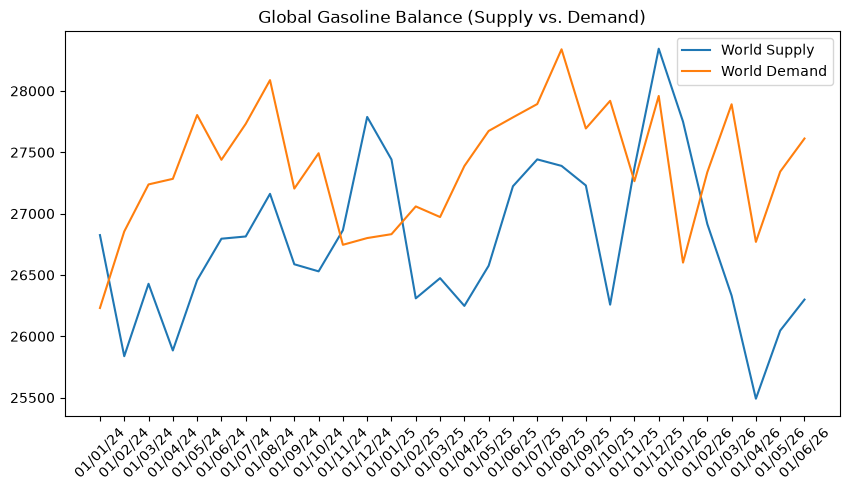

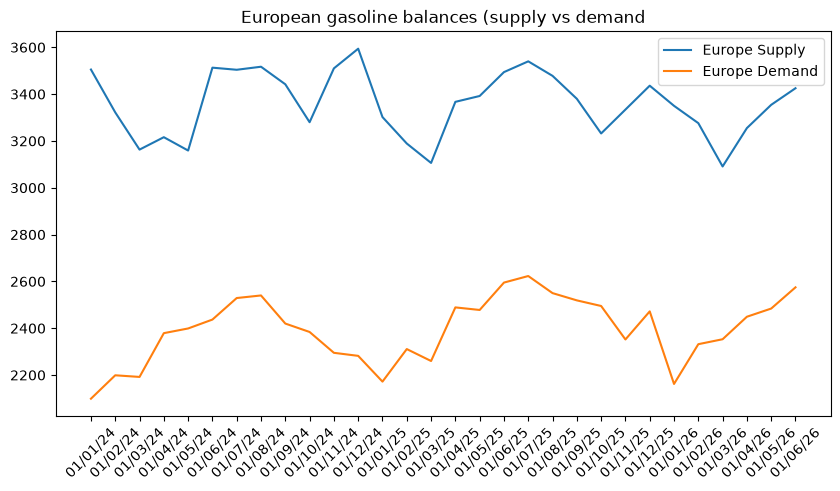

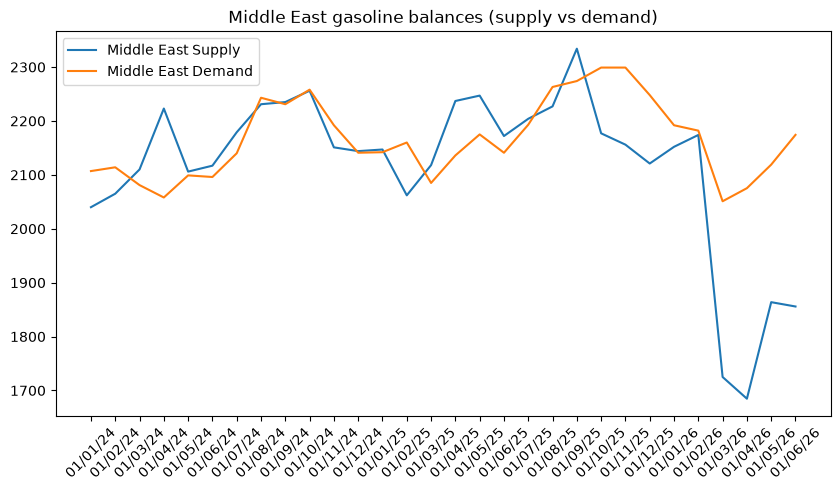

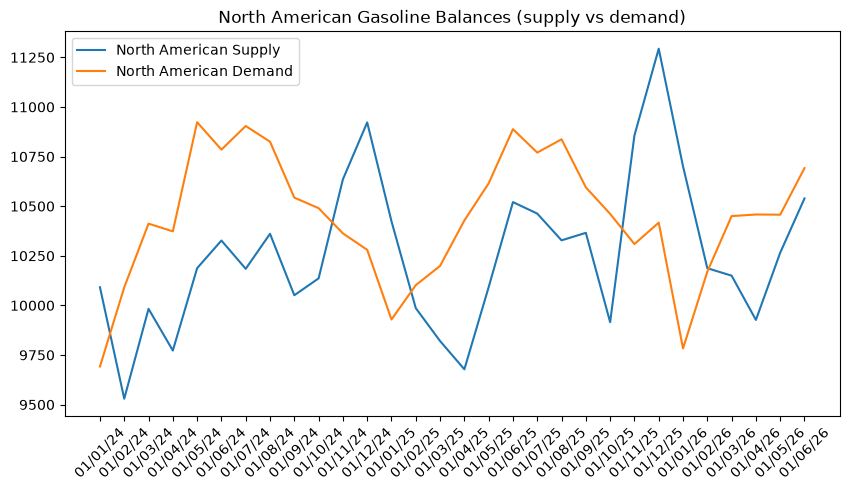

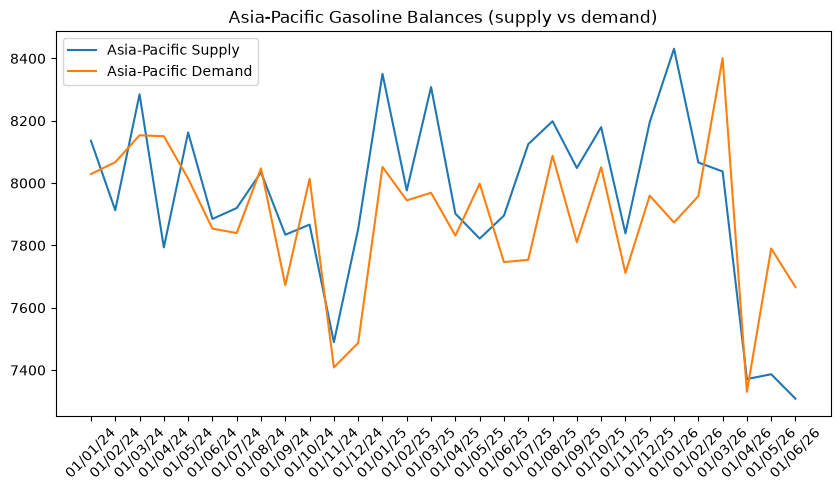

In [4]:
#plotting gasoline balances 
import matplotlib.pyplot as plt

#world level, using world_supply_kbd and world_demand_kbd
plt.figure(figsize=(10,5))

plt.plot(gasolineBalances["date"], gasolineBalances["world_supply_kbd"], label= "World Supply")
plt.plot(gasolineBalances["date"], gasolineBalances["world_demand_kbd"], label = "World Demand")

plt.legend()
plt.title("Global Gasoline Balance (Supply vs. Demand)")
plt.xticks(rotation = 45)
plt.show()


#regionally
#europe
plt.figure(figsize = (10,5))

plt.plot(gasolineBalances["date"], gasolineBalances["europe_supply_kbd"],label="Europe Supply")
plt.plot(gasolineBalances["date"], gasolineBalances["europe_demand_kbd"], label = "Europe Demand")

plt.legend()
plt.title("European gasoline balances (supply vs demand")
plt.xticks(rotation=45)
plt.show()

#middle east
plt.figure(figsize = (10,5))

plt.plot(gasolineBalances["date"], gasolineBalances["middle_east_supply_kbd"], label = "Middle East Supply")
plt.plot(gasolineBalances["date"], gasolineBalances["middle_east_demand_kbd"], label = "Middle East Demand")

plt.legend()
plt.title("Middle East gasoline balances (supply vs demand)")
plt.xticks(rotation = 45)
plt.show()

#north america
plt.figure(figsize = (10,5))

plt.plot(gasolineBalances["date"], gasolineBalances["north_america_supply_kbd"], label = "North American Supply")
plt.plot(gasolineBalances["date"], gasolineBalances["north_america_demand_kbd"], label = "North American Demand")

plt.legend()
plt.title("North American Gasoline Balances (supply vs demand)")
plt.xticks(rotation = 45)
plt.show()

#asia
plt.figure(figsize = (10,5))

plt.plot(gasolineBalances["date"], gasolineBalances["asia_pacific_supply_kbd"], label = "Asia-Pacific Supply")
plt.plot(gasolineBalances["date"], gasolineBalances["asia_pacific_demand_kbd"], label = "Asia-Pacific Demand")

plt.legend()
plt.title("Asia-Pacific Gasoline Balances (supply vs demand)")
plt.xticks(rotation = 45)
plt.show()








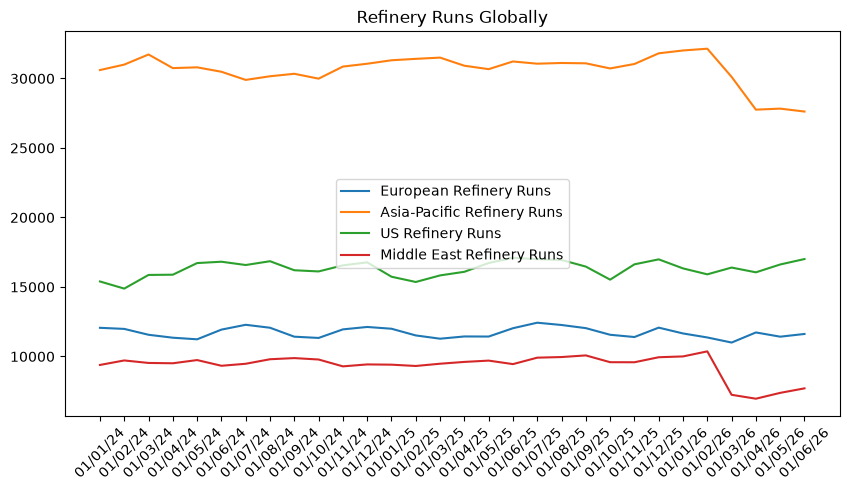

In [5]:
#refinery runs

#europe
plt.figure(figsize=(10,5))

plt.plot(refineryRuns["date"], refineryRuns["europe_refinery_runs_kbd"], label = "European Refinery Runs")
plt.plot(refineryRuns["date"], refineryRuns["asia_pacific_refinery_runs_kbd"], label = "Asia-Pacific Refinery Runs")
plt.plot(refineryRuns["date"], refineryRuns["united_states_refinery_runs_kbd"], label = "US Refinery Runs")
plt.plot(refineryRuns["date"], refineryRuns["middle_east_refinery_runs_kbd"], label = "Middle East Refinery Runs")

plt.legend(loc = "center")
plt.title("Refinery Runs Globally")
plt.xticks(rotation=45)
plt.show()


In [6]:
#making a correlation matrix from a small subset of the data, making a new dataset first
cmSet = refineryRuns[["world_refinery_runs_kbd", "united_states_refinery_runs_kbd"]].copy()

cmSet["world_gasoline_demand_kbd"] = gasolineBalances["world_demand_kbd"]
cmSet["world_gasoline_supply_kbd"] = gasolineBalances["world_supply_kbd"]
cmSet["ras_tanura_chiba_ws_rates"] = lhRates["ras_tanura_chiba_clean_55k_ws"]
cmSet["houston_amsterdam_ws_rates"] = lhRates["houston_amsterdam_lr1_clean_60k_ws"]


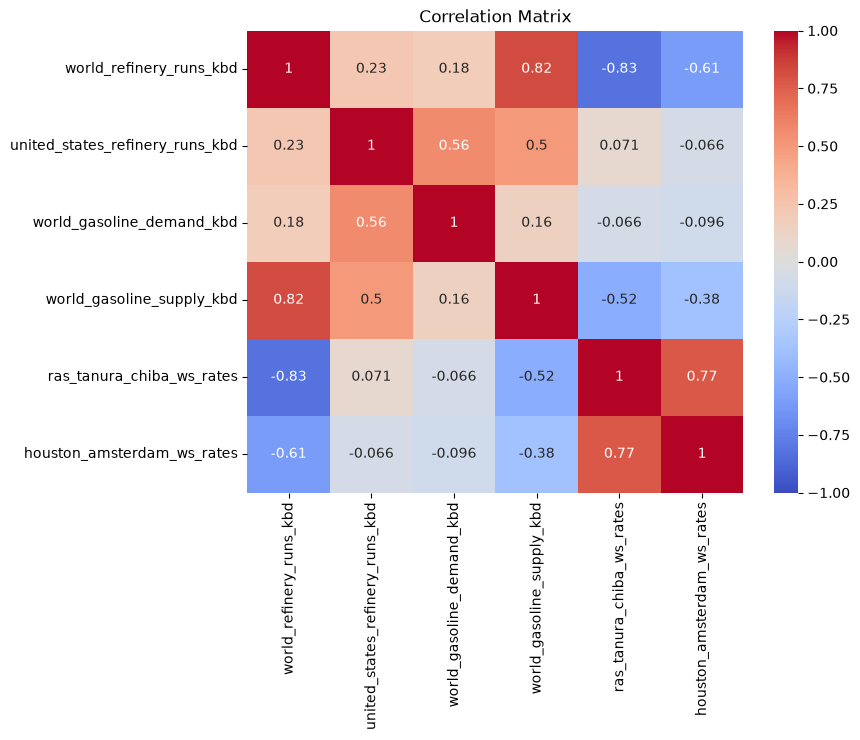

In [7]:
#making matrix
import seaborn as sns

corr = cmSet.corr(numeric_only = True)

plt.figure(figsize= (8,6))

sns.heatmap(corr, annot=True, cmap = "coolwarm", vmin=-1, vmax =1)
plt.title("Correlation Matrix")
plt.show()


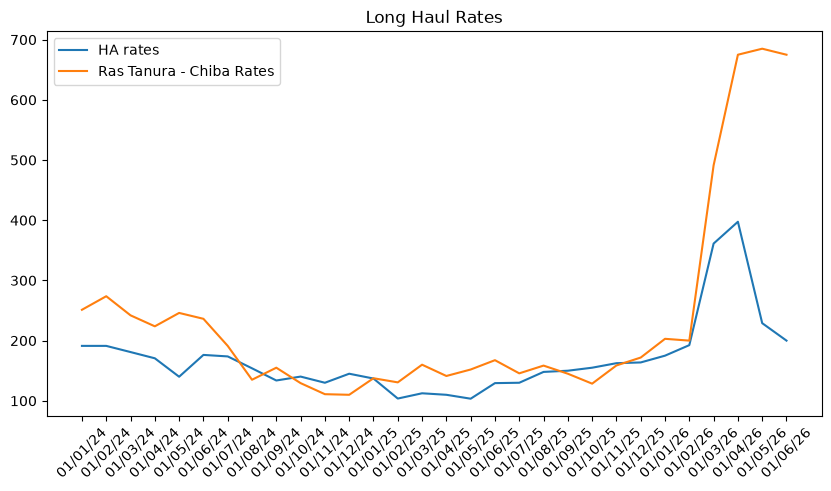

In [8]:
import matplotlib.pyplot as plt
#plotting both spot rates

plt.figure(figsize = (10,5))

plt.plot(lhRates["date"], lhRates["houston_amsterdam_lr1_clean_60k_ws"], label = "HA rates")
plt.plot(lhRates["date"], lhRates["ras_tanura_chiba_clean_55k_ws"], label = "Ras Tanura - Chiba Rates")

plt.legend()
plt.title("Long Haul Rates")
plt.xticks(rotation = 45)
plt.show()

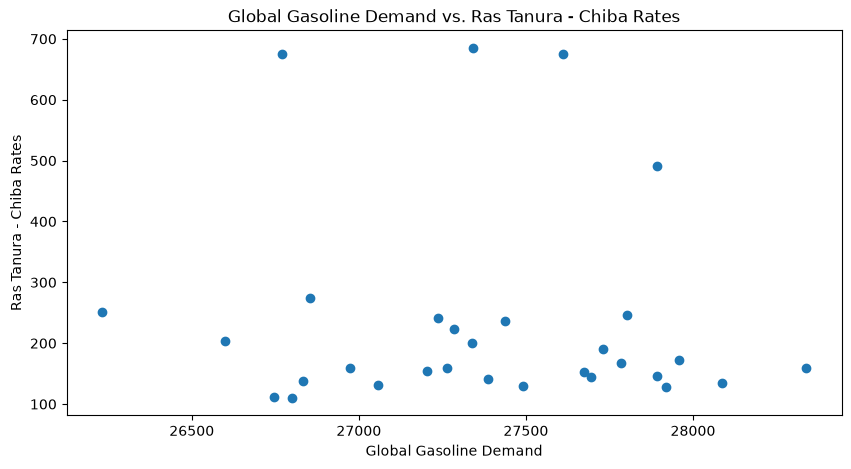

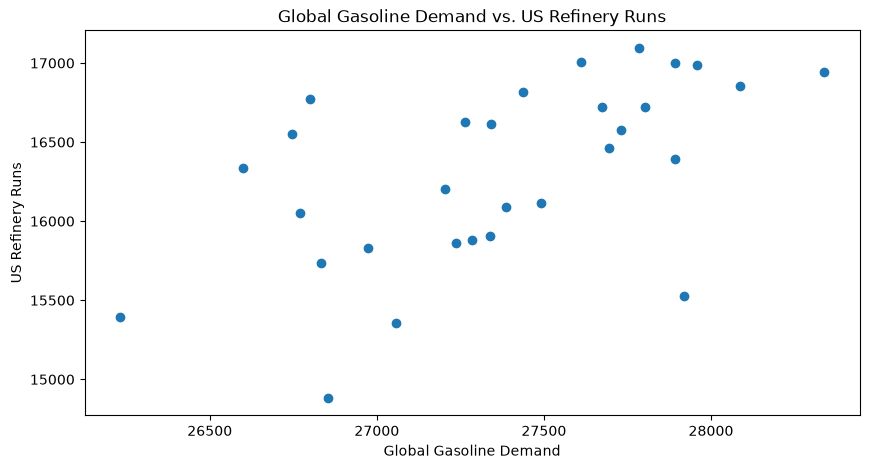

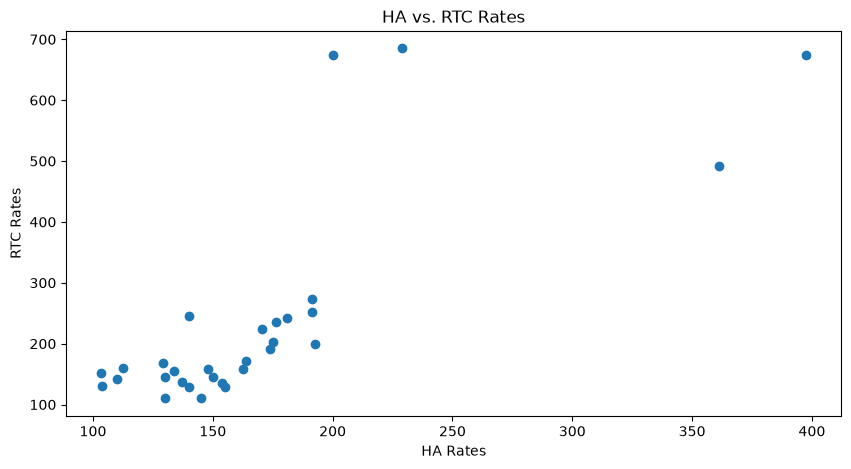

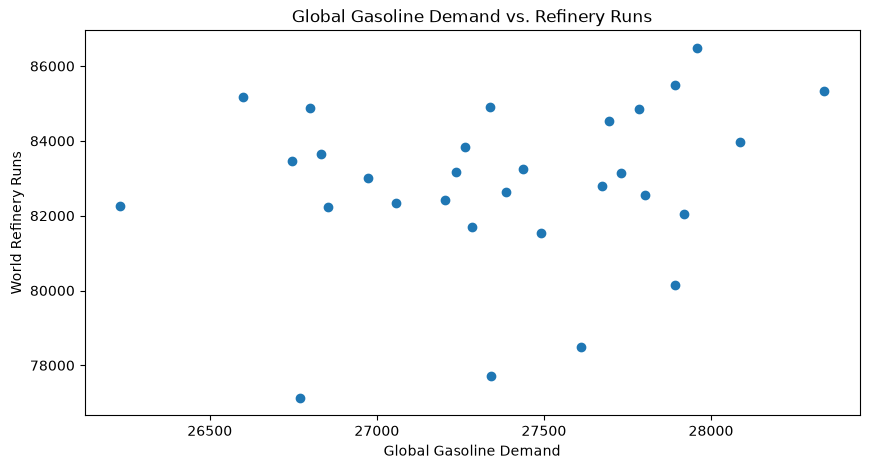

In [9]:
#looking at correlated variables 

#high negative: ras tanura-chiba and world refinery runs
plt.figure(figsize=(10,5))
plt.scatter(cmSet["world_gasoline_demand_kbd"], cmSet["ras_tanura_chiba_ws_rates"])
plt.xlabel("Global Gasoline Demand")
plt.ylabel("Ras Tanura - Chiba Rates")
plt.title("Global Gasoline Demand vs. Ras Tanura - Chiba Rates")
plt.show()

#high postive: refinery runs and supply (more intuitive), US refinery runs and world gasoline demand, ras tanura-chiba rates and houston-rotterdam rates

plt.figure(figsize= (10,5))
plt.scatter(cmSet["world_gasoline_demand_kbd"], cmSet["united_states_refinery_runs_kbd"])
plt.xlabel("Global Gasoline Demand")
plt.ylabel("US Refinery Runs")
plt.title("Global Gasoline Demand vs. US Refinery Runs")
plt.show()

plt.figure(figsize=(10,5))
plt.scatter(cmSet["houston_amsterdam_ws_rates"], cmSet["ras_tanura_chiba_ws_rates"])
plt.xlabel("HA Rates")
plt.ylabel("RTC Rates")
plt.title("HA vs. RTC Rates")
plt.show()

plt.figure(figsize=(10,5))
plt.scatter(cmSet["world_gasoline_demand_kbd"], cmSet["world_refinery_runs_kbd"])
plt.xlabel("Global Gasoline Demand")
plt.ylabel("World Refinery Runs")
plt.title("Global Gasoline Demand vs. Refinery Runs")
plt.show()

In [10]:
#new datasets to investigate other variables. vessel supply, fuel prices, and port congestion 
fuelPrices = pd.read_csv("middle_distillates_price_forecast_clean.csv")

fuelPrices.head()
fuelPrices.describe()
fuelPrices.info()
fuelPrices.columns

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   30 non-null     str    
 1   jet_nwe_usd_per_t      30 non-null     float64
 2   jet_nwe_usd_per_bbl    30 non-null     float64
 3   ulsd_nwe_usd_per_t     30 non-null     float64
 4   ulsd_nwe_usd_per_bbl   30 non-null     float64
 5   gasoil_sg_usd_per_t    30 non-null     float64
 6   gasoil_sg_usd_per_bbl  30 non-null     float64
 7   ulsd_sg_usd_per_t      30 non-null     float64
 8   ulsd_sg_usd_per_bbl    30 non-null     float64
 9   jet_sg_usd_per_bbl     30 non-null     float64
 10  ulsd_usgc_usd_per_bbl  30 non-null     float64
dtypes: float64(10), str(1)
memory usage: 2.7 KB


Index(['date', 'jet_nwe_usd_per_t', 'jet_nwe_usd_per_bbl',
       'ulsd_nwe_usd_per_t', 'ulsd_nwe_usd_per_bbl', 'gasoil_sg_usd_per_t',
       'gasoil_sg_usd_per_bbl', 'ulsd_sg_usd_per_t', 'ulsd_sg_usd_per_bbl',
       'jet_sg_usd_per_bbl', 'ulsd_usgc_usd_per_bbl'],
      dtype='str')

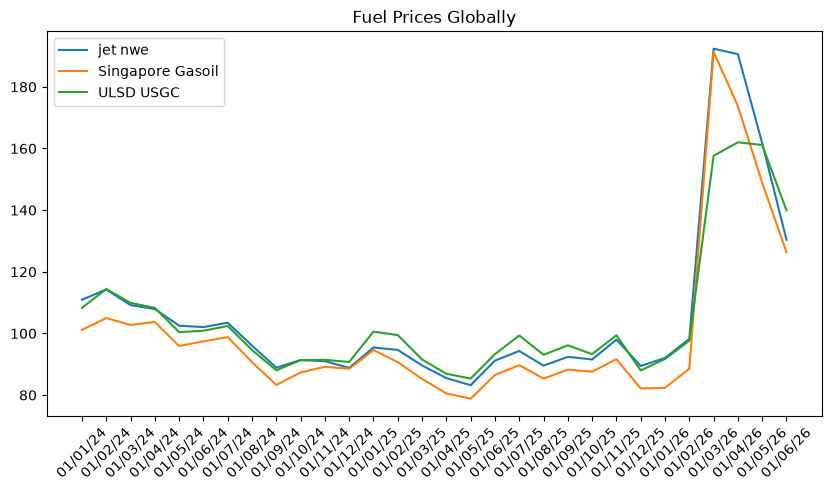

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [11]:
plt.figure(figsize = (10,5))

plt.plot(fuelPrices["date"], fuelPrices["jet_nwe_usd_per_bbl"], label = "jet nwe")
plt.plot(fuelPrices["date"], fuelPrices["gasoil_sg_usd_per_bbl"], label = "Singapore Gasoil")
plt.plot(fuelPrices["date"], fuelPrices["ulsd_usgc_usd_per_bbl"], label = "ULSD USGC")

plt.legend()
plt.title("Fuel Prices Globally")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))

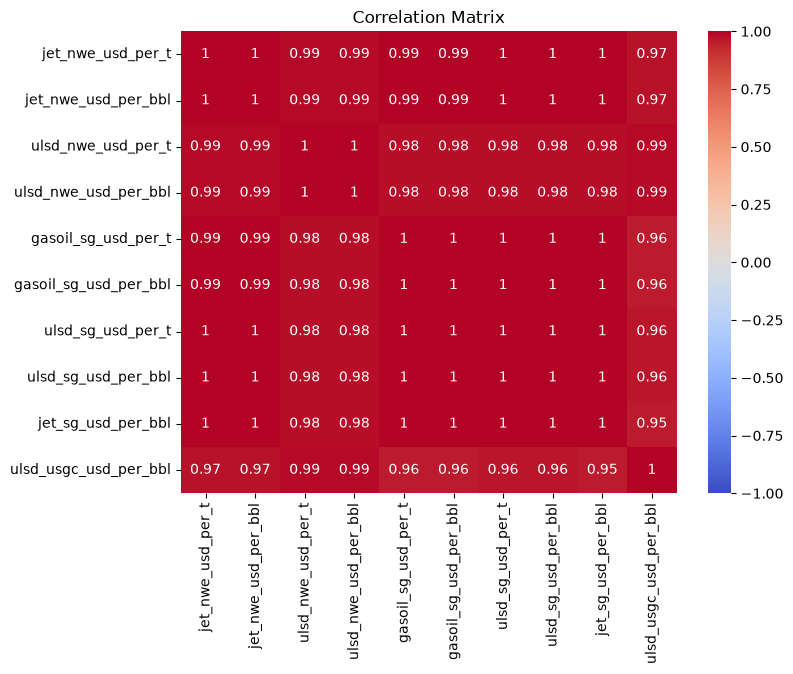

In [12]:
#testing correlation matrix
corr = fuelPrices.corr(numeric_only = True)
plt.figure(figsize = (8,6))
sns.heatmap(corr, annot = True, cmap = "coolwarm", vmin = -1, vmax =1)
plt.title("Correlation Matrix")
plt.show()

In [45]:
#analyzing potential indicators 
indicators = pd.read_csv("indicators-clean.csv")

indicators["Date"] = pd.to_datetime(indicators["Date"], errors = "coerce")

indicators.head()
indicators.describe()
indicators.info()
indicators.columns 

<class 'pandas.DataFrame'>
RangeIndex: 138 entries, 0 to 137
Data columns (total 29 columns):
 #   Column                                                               Non-Null Count  Dtype         
---  ------                                                               --------------  -----         
 0   Date                                                                 138 non-null    datetime64[us]
 1   Product Tankers MR and above - Idle (No)                             138 non-null    float64       
 2   Product Tankers MR and above - Idle (DWT million)                    138 non-null    float64       
 3   Product Tankers MR and above - % Idle (No)                           138 non-null    float64       
 4   Product Tankers MR and above - % Idle (DWT million)                  138 non-null    float64       
 5   LR1 Trading Fleet (DWT million)                                      138 non-null    float64       
 6   LR1 Trading Fleet Growth (% Yr/Yr)                           

Index(['Date', 'Product Tankers MR and above - Idle (No)',
       'Product Tankers MR and above - Idle (DWT million)',
       'Product Tankers MR and above - % Idle (No)',
       'Product Tankers MR and above - % Idle (DWT million)',
       'LR1 Trading Fleet (DWT million)', 'LR1 Trading Fleet Growth (% Yr/Yr)',
       'LR2 Trading Fleet (DWT million)', 'LR2 Trading Fleet Growth (% Yr/Yr)',
       'MR Product Tanker 40,000-54,999 dwt Fleet Development (No)',
       'MR Product Tanker 40,000-54,999 dwt Fleet Development (DWT million)',
       'MR Product Tanker 40,000-54,999 dwt Fleet Growth (% Yr/Yr)',
       'Total Product Tanker 10k+ DWT Demolition (No)',
       'Total Product Tanker 10k+ DWT Demolition (DWT million)',
       'MR Product Tanker 40,000-54,999 DWT Demolition (No)',
       'MR Product Tanker 40,000-54,999 DWT Demolition (DWT)',
       'MR Product Tanker 40,000-54,999 dwt Orderbook (No)',
       'MR Product Tanker 40,000-54,999 dwt Orderbook (DWT)',
       'Product Tanke

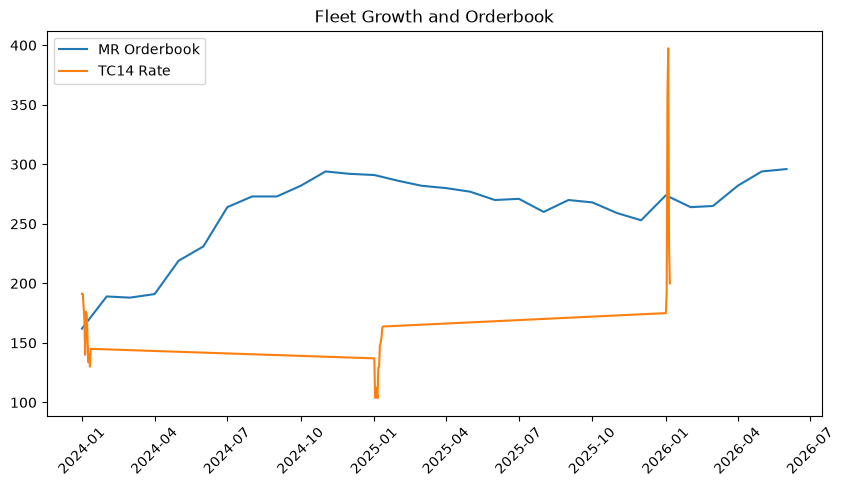

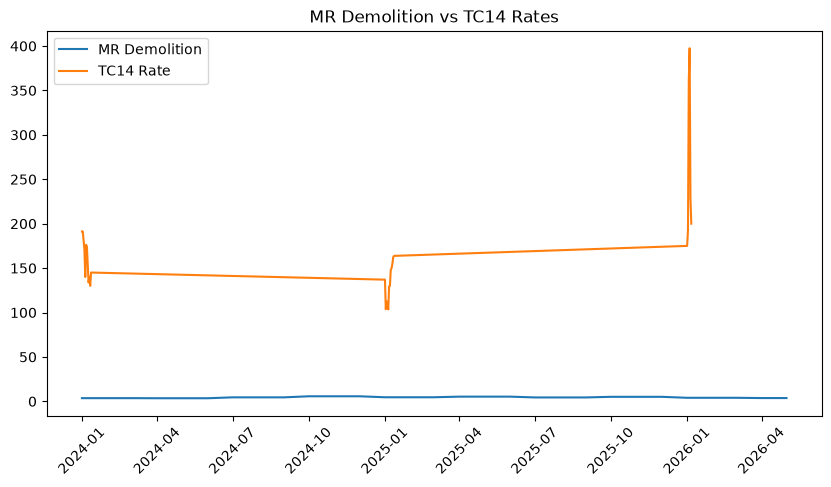

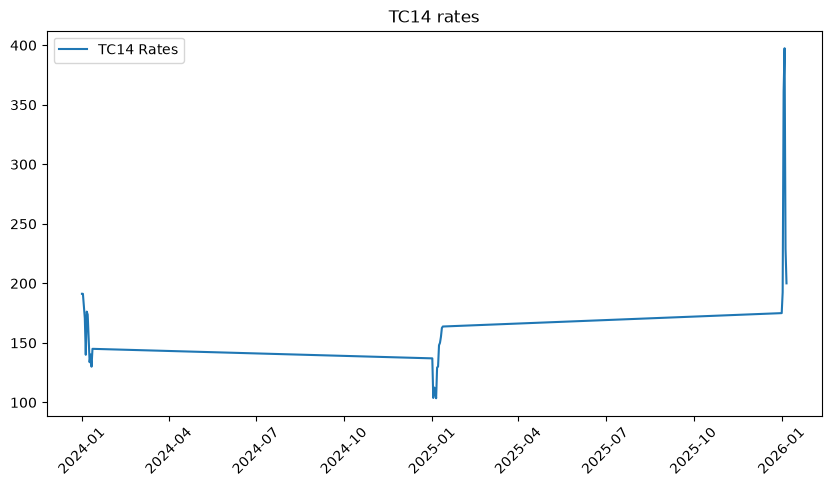

In [ ]:
#eda on idicators set
#sns.pairplot(indicators)

#fleet growth and orderbook
#align dates first
common_start_date= lhRates["date"].min()
adjusted_indicators = indicators[indicators["Date"] >= common_start_date]
plt.figure(figsize=(10,5))
#plt.plot(indicators["Date"], indicators["MR Product Tanker 40,000-54,999 dwt Fleet Development (DWT million)"], label = "MR Development")
plt.plot(adjusted_indicators["Date"], adjusted_indicators["MR Product Tanker 40,000-54,999 dwt Orderbook (No)"], label = "MR Orderbook")
plt.plot(lhRates["date"], lhRates["houston_amsterdam_lr1_clean_60k_ws"], label = "TC14 Rate")
plt.legend()
plt.title("Fleet Growth and Orderbook")
plt.xticks(rotation=45)
plt.show()


#fleet demolition/idle 
csd_demo = lhRates["date"].min()
adj_indicators_demo = indicators[indicators["Date"] >= csd_demo]
adj_indicators_demo = adj_indicators_demo.dropna(
    subset=["Date", "MR Product Tanker 40,000-54,999 DWT Demolition (DWT)"]
)
plt.figure(figsize= (10,5))
plt.plot(adj_indicators_demo["Date"], adj_indicators_demo["Product Tankers MR and above - % Idle (No)"], label = "Product Tankers Idle")
plt.plot(lhRates["date"], lhRates["houston_amsterdam_lr1_clean_60k_ws"], label = "TC14 Rate")
plt.legend()
plt.title("MR Demolition vs TC14 Rates")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize = (10,5))
plt.plot(lhRates["date"], lhRates["houston_amsterdam_lr1_clean_60k_ws"], label = "TC14 Rates")
plt.legend()
plt.title("TC14 rates")
plt.xticks(rotation=45)
plt.show()